# Predictive Analytics for Healthcare: Forecasting Patient Length of Stay in Urban Hospitals

## IDRA Data Science & AI Capstone Project

### Objective
To analyse patient and hospital-related characteristics and develop a regression model to predict patient length of stay.

In [2]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

print("File uploaded successfully!")

Saving P_1_LengthOfStay.csv to P_1_LengthOfStay.csv
File uploaded successfully!


In [4]:
file_name = "P_1_LengthOfStay.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (61680, 28)


In [5]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [6]:
print("Last 5 rows:")
display(df.tail())

Last 5 rows:


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
61675,61676,8/26/2012,0,F,0,0,0,0,0,0,0,0,0,0,1,9.2,6.0,135.580481,191.582181,118.25,1.071236,27.527424,79,6.2,3,8/30/2012,B,4
61676,61677,8/5/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,14.1,10.1,136.502279,106.496905,14.00,1.323255,28.859144,74,7.8,0,8/7/2012,B,2
61677,61678,11/26/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.0,7.1,133.789389,111.681658,12.00,1.137207,28.129458,71,6.5,3,11/27/2012,A,1
61678,61679,6/11/2012,0,F,0,0,0,0,0,1,0,0,0,0,0,8.9,7.1,140.014391,139.819270,12.00,0.881512,27.460717,57,7.4,1,6/16/2012,E,5
61679,61680,8/11/2012,0,F,0,0,0,0,0,1,0,0,0,0,0,8.7,11.7,133.219558,144.418523,12.00,1.045885,28.060491,89,6.5,1,8/16/2012,E,5


In [7]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61680 entries, 0 to 61679
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   eid                         61680 non-null  int64  
 1   vdate                       61680 non-null  object 
 2   rcount                      61680 non-null  object 
 3   gender                      61680 non-null  object 
 4   dialysisrenalendstage       61680 non-null  int64  
 5   asthma                      61680 non-null  int64  
 6   irondef                     61680 non-null  int64  
 7   pneum                       61680 non-null  int64  
 8   substancedependence         61680 non-null  int64  
 9   psychologicaldisordermajor  61680 non-null  int64  
 10  depress                     61680 non-null  int64  
 11  psychother                  61680 non-null  int64  
 12  fibrosisandother            61680 non-null  int64  
 13  malnutriti

In [8]:
print("Columns in the dataset:")

for i, column in enumerate(df.columns, start=1):
    print(i, ".", column)

Columns in the dataset:
1 . eid
2 . vdate
3 . rcount
4 . gender
5 . dialysisrenalendstage
6 . asthma
7 . irondef
8 . pneum
9 . substancedependence
10 . psychologicaldisordermajor
11 . depress
12 . psychother
13 . fibrosisandother
14 . malnutrition
15 . hemo
16 . hematocrit
17 . neutrophils
18 . sodium
19 . glucose
20 . bloodureanitro
21 . creatinine
22 . bmi
23 . pulse
24 . respiration
25 . secondarydiagnosisnonicd9
26 . discharged
27 . facid
28 . lengthofstay


In [9]:
print("Data types of all columns:")

display(df.dtypes.to_frame(name="Data Type"))

Data types of all columns:


,Data Type
eid,int64
vdate,object
rcount,object
gender,object
dialysisrenalendstage,int64
asthma,int64
irondef,int64
pneum,int64
substancedependence,int64
psychologicaldisordermajor,int64


In [10]:
missing_count = df.isnull().sum()

missing_percentage = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_table)

,Missing Values,Missing Percentage
eid,0,0.0
vdate,0,0.0
rcount,0,0.0
gender,0,0.0
dialysisrenalendstage,0,0.0
asthma,0,0.0
irondef,0,0.0
pneum,0,0.0
substancedependence,0,0.0
psychologicaldisordermajor,0,0.0


In [11]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
print("Descriptive statistics for numerical variables:")

display(df.describe().T)

Descriptive statistics for numerical variables:


,count,mean,std,min,25%,50%,75%,max
eid,61680.0,30840.500000,17805.626639,1.000000,15420.750000,30840.500000,46260.250000,61680.000000
dialysisrenalendstage,61680.0,0.036365,0.187198,0.000000,0.000000,0.000000,0.000000,1.000000
asthma,61680.0,0.034679,0.182967,0.000000,0.000000,0.000000,0.000000,1.000000
irondef,61680.0,0.095542,0.293964,0.000000,0.000000,0.000000,0.000000,1.000000
pneum,61680.0,0.039559,0.194922,0.000000,0.000000,0.000000,0.000000,1.000000
substancedependence,61680.0,0.062954,0.242882,0.000000,0.000000,0.000000,0.000000,1.000000
psychologicaldisordermajor,61680.0,0.236106,0.424691,0.000000,0.000000,0.000000,0.000000,1.000000
depress,61680.0,0.052205,0.222442,0.000000,0.000000,0.000000,0.000000,1.000000
psychother,61680.0,0.049935,0.217813,0.000000,0.000000,0.000000,0.000000,1.000000
fibrosisandother,61680.0,0.004864,0.069572,0.000000,0.000000,0.000000,0.000000,1.000000


In [14]:
print("Descriptive statistics for numerical variables:")

display(df.describe().T)

Descriptive statistics for numerical variables:


,count,mean,std,min,25%,50%,75%,max
eid,61680.0,30840.500000,17805.626639,1.000000,15420.750000,30840.500000,46260.250000,61680.000000
dialysisrenalendstage,61680.0,0.036365,0.187198,0.000000,0.000000,0.000000,0.000000,1.000000
asthma,61680.0,0.034679,0.182967,0.000000,0.000000,0.000000,0.000000,1.000000
irondef,61680.0,0.095542,0.293964,0.000000,0.000000,0.000000,0.000000,1.000000
pneum,61680.0,0.039559,0.194922,0.000000,0.000000,0.000000,0.000000,1.000000
substancedependence,61680.0,0.062954,0.242882,0.000000,0.000000,0.000000,0.000000,1.000000
psychologicaldisordermajor,61680.0,0.236106,0.424691,0.000000,0.000000,0.000000,0.000000,1.000000
depress,61680.0,0.052205,0.222442,0.000000,0.000000,0.000000,0.000000,1.000000
psychother,61680.0,0.049935,0.217813,0.000000,0.000000,0.000000,0.000000,1.000000
fibrosisandother,61680.0,0.004864,0.069572,0.000000,0.000000,0.000000,0.000000,1.000000


In [15]:
print("Target variable: lengthofstay")

print("\nBasic statistics:")
print(df["lengthofstay"].describe())

print("\nUnique values:")
print(sorted(df["lengthofstay"].unique()))

Target variable: lengthofstay

Basic statistics:
count    61680.000000
mean         3.999368
std          2.357744
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         17.000000
Name: lengthofstay, dtype: float64

Unique values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]


In [16]:
los_counts = df["lengthofstay"].value_counts().sort_index()

display(los_counts.to_frame(name="Number of Patients"))

,Number of Patients
lengthofstay,
1,11106
2,7947
3,9805
4,9111
5,7589
6,6411
7,4483
8,2837
9,1333


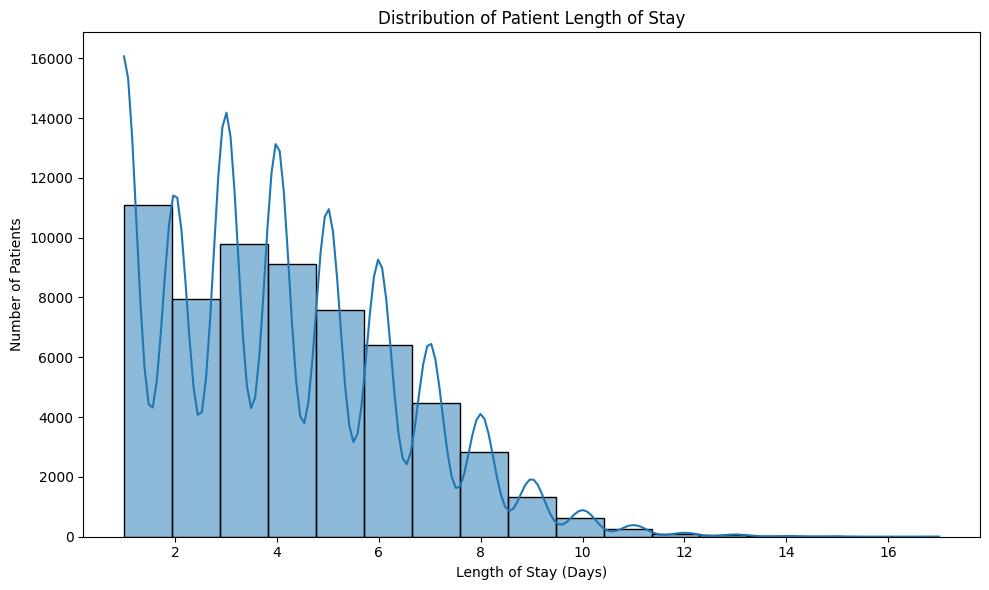

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["lengthofstay"],
    bins=17,
    kde=True
)

plt.title("Distribution of Patient Length of Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

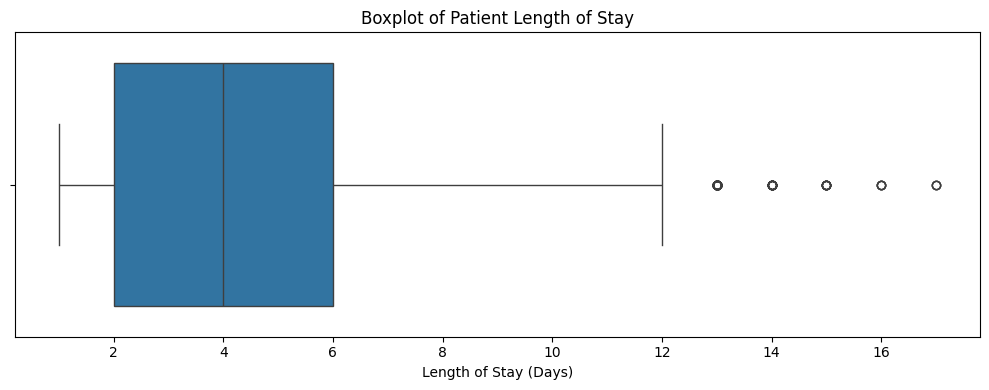

In [18]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["lengthofstay"])

plt.title("Boxplot of Patient Length of Stay")
plt.xlabel("Length of Stay (Days)")

plt.tight_layout()
plt.show()

In [19]:
df["vdate"] = pd.to_datetime(df["vdate"], errors="coerce")
df["discharged"] = pd.to_datetime(df["discharged"], errors="coerce")

print("Date columns converted successfully!")

display(df[["vdate", "discharged"]].head())

Date columns converted successfully!


,vdate,discharged
0,2012-08-29,2012-09-01
1,2012-05-26,2012-06-02
2,2012-09-22,2012-09-25
3,2012-08-09,2012-08-10
4,2012-12-20,2012-12-24


In [20]:
df["vdate"] = pd.to_datetime(df["vdate"], errors="coerce")
df["discharged"] = pd.to_datetime(df["discharged"], errors="coerce")

print("Date columns converted successfully!")

display(df[["vdate", "discharged"]].head())

Date columns converted successfully!


,vdate,discharged
0,2012-08-29,2012-09-01
1,2012-05-26,2012-06-02
2,2012-09-22,2012-09-25
3,2012-08-09,2012-08-10
4,2012-12-20,2012-12-24


In [21]:
print("Checking important numerical variables for invalid values:")

numerical_columns = df.select_dtypes(include=np.number).columns

invalid_summary = pd.DataFrame({
    "Minimum": df[numerical_columns].min(),
    "Maximum": df[numerical_columns].max(),
    "Mean": df[numerical_columns].mean(),
    "Missing": df[numerical_columns].isnull().sum()
})

display(invalid_summary)

Checking important numerical variables for invalid values:


,Minimum,Maximum,Mean,Missing
eid,1.000000,61680.000000,30840.500000,0
dialysisrenalendstage,0.000000,1.000000,0.036365,0
asthma,0.000000,1.000000,0.034679,0
irondef,0.000000,1.000000,0.095542,0
pneum,0.000000,1.000000,0.039559,0
substancedependence,0.000000,1.000000,0.062954,0
psychologicaldisordermajor,0.000000,1.000000,0.236106,0
depress,0.000000,1.000000,0.052205,0
psychother,0.000000,1.000000,0.049935,0
fibrosisandother,0.000000,1.000000,0.004864,0


In [23]:
numeric_for_outliers = [
    "hematocrit",
    "neutrophils",
    "sodium",
    "glucose",
    "bloodureanitro",
    "creatinine",
    "bmi",
    "pulse",
    "respiration",
    "lengthofstay"
]

outlier_results = []

for column in numeric_for_outliers:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = ((df[column] < lower_limit) |
                (df[column] > upper_limit)).sum()

    outlier_results.append([
        column,
        Q1,
        Q3,
        IQR,
        lower_limit,
        upper_limit,
        outliers
    ])

outlier_table = pd.DataFrame(
    outlier_results,
    columns=[
        "Variable",
        "Q1",
        "Q3",
        "IQR",
        "Lower Limit",
        "Upper Limit",
        "Potential Outliers"
    ]
)

display(outlier_table)

,Variable,Q1,Q3,IQR,Lower Limit,Upper Limit,Potential Outliers
0,hematocrit,10.900000,12.900000,2.000000,7.900000,15.900000,3497
1,neutrophils,7.700000,11.500000,3.800000,2.000000,17.200000,4071
2,sodium,135.874040,139.914345,4.040305,129.813582,145.974804,464
3,glucose,121.873358,162.207568,40.334210,61.372043,222.708882,441
4,bloodureanitro,11.000000,14.000000,3.000000,6.500000,18.500000,12043
5,creatinine,0.964564,1.235104,0.270540,0.558754,1.640915,411
6,bmi,28.456682,31.152721,2.696039,24.412624,35.196780,420
7,pulse,66.000000,81.000000,15.000000,43.500000,103.500000,658
8,respiration,6.500000,6.500000,0.000000,6.500000,6.500000,21856
9,lengthofstay,2.000000,6.000000,4.000000,-4.000000,12.000000,83


In [24]:
clean_df = df.copy()

print("Clean dataset created.")
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])

Clean dataset created.
Rows: 61680
Columns: 28


In [25]:
before_duplicates = len(clean_df)

clean_df = clean_df.drop_duplicates()

after_duplicates = len(clean_df)

print("Rows before duplicate removal:", before_duplicates)
print("Rows after duplicate removal:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

Rows before duplicate removal: 61680
Rows after duplicate removal: 61680
Duplicates removed: 0


In [26]:
print("Missing values after cleaning:")

missing_after = clean_df.isnull().sum()

display(
    missing_after[missing_after > 0].to_frame(name="Missing Values")
)

Missing values after cleaning:


,Missing Values


In [27]:
clean_df["admission_year"] = clean_df["vdate"].dt.year
clean_df["admission_month"] = clean_df["vdate"].dt.month
clean_df["admission_dayofweek"] = clean_df["vdate"].dt.dayofweek

print("Date-based features created successfully!")

display(
    clean_df[
        ["vdate", "admission_year", "admission_month", "admission_dayofweek"]
    ].head()
)

Date-based features created successfully!


,vdate,admission_year,admission_month,admission_dayofweek
0,2012-08-29,2012,8,2
1,2012-05-26,2012,5,5
2,2012-09-22,2012,9,5
3,2012-08-09,2012,8,3
4,2012-12-20,2012,12,3


In [28]:
monthly_los = (
    clean_df
    .groupby("admission_month")["lengthofstay"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(monthly_los)

,admission_month,count,mean,median
0,1,5231,4.030396,4.0
1,2,4944,3.952468,4.0
2,3,5229,4.027730,4.0
3,4,4909,3.980648,4.0
4,5,5201,4.023842,4.0
5,6,5093,4.003142,4.0
6,7,5254,4.001523,4.0
7,8,5205,4.007685,4.0
8,9,5114,4.031873,4.0
9,10,5316,3.967645,4.0


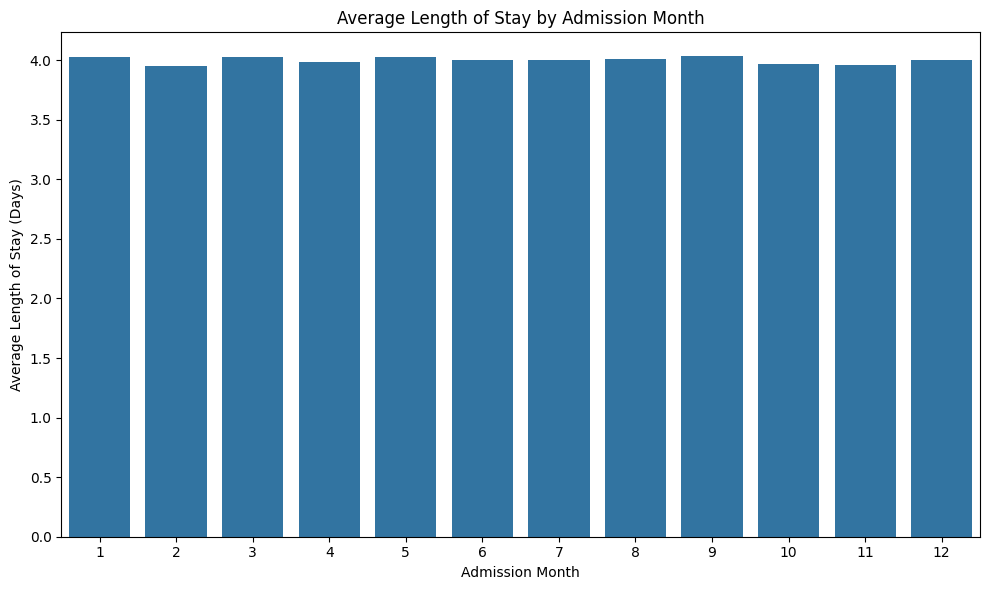

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=monthly_los,
    x="admission_month",
    y="mean"
)

plt.title("Average Length of Stay by Admission Month")
plt.xlabel("Admission Month")
plt.ylabel("Average Length of Stay (Days)")

plt.tight_layout()
plt.show()

In [30]:
gender_los = (
    clean_df
    .groupby("gender")["lengthofstay"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(gender_los)

,gender,count,mean,median
0,F,35704,3.866962,4.0
1,M,25976,4.181360,4.0


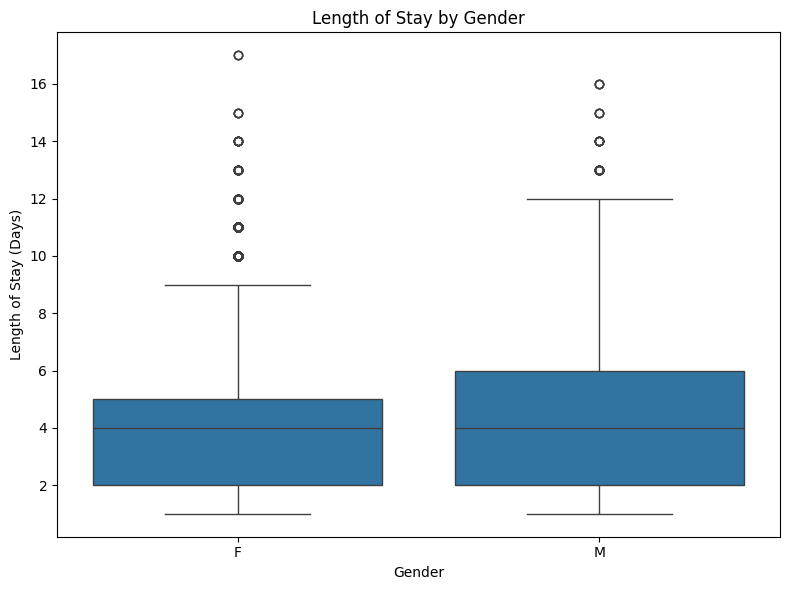

In [31]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=clean_df,
    x="gender",
    y="lengthofstay"
)

plt.title("Length of Stay by Gender")
plt.xlabel("Gender")
plt.ylabel("Length of Stay (Days)")

plt.tight_layout()
plt.show()

In [32]:
facility_los = (
    clean_df
    .groupby("facid")["lengthofstay"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(facility_los)

,facid,count,mean,median
0,A,18657,3.277912,3.0
1,B,18470,3.285490,3.0
2,C,2899,4.915143,5.0
3,D,2774,4.820836,4.0
4,E,18880,5.149364,5.0


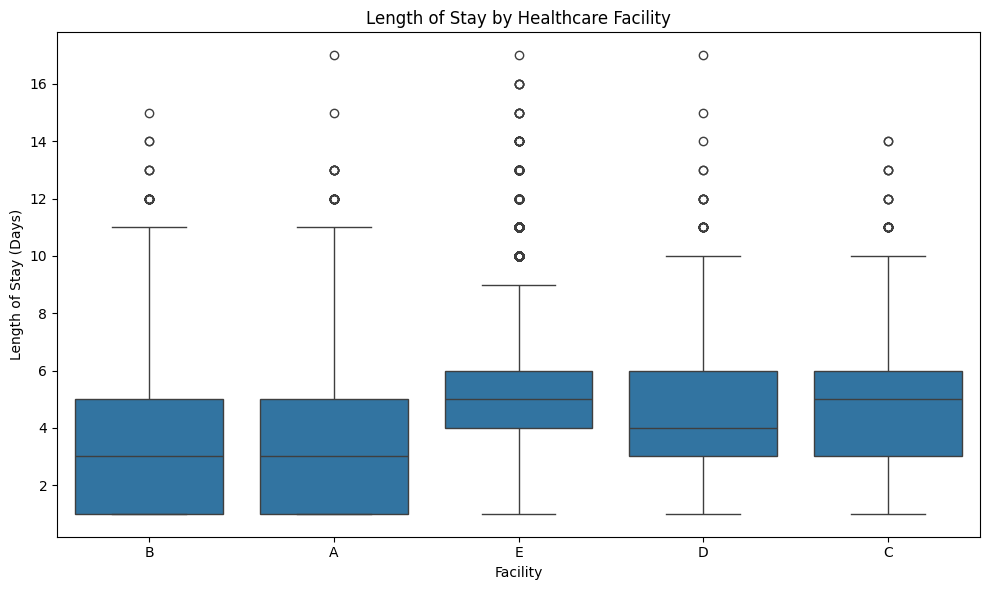

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clean_df,
    x="facid",
    y="lengthofstay"
)

plt.title("Length of Stay by Healthcare Facility")
plt.xlabel("Facility")
plt.ylabel("Length of Stay (Days)")

plt.tight_layout()
plt.show()

In [34]:
condition_columns = [
    "dialysisrenalendstage",
    "asthma",
    "irondef",
    "pneum",
    "substancedependence",
    "psychologicaldisordermajor",
    "depress",
    "psychother",
    "fibrosisandother",
    "malnutrition",
    "hemo"
]

condition_results = []

for column in condition_columns:

    result = clean_df.groupby(column)["lengthofstay"].mean()

    for category, mean_los in result.items():
        condition_results.append([
            column,
            category,
            mean_los
        ])

condition_table = pd.DataFrame(
    condition_results,
    columns=["Condition", "Condition Status", "Average Length of Stay"]
)

display(condition_table)

,Condition,Condition Status,Average Length of Stay
0,dialysisrenalendstage,0,3.921362
1,dialysisrenalendstage,1,6.066429
2,asthma,0,3.962060
3,asthma,1,5.037868
4,irondef,0,3.850485
5,irondef,1,5.408790
6,pneum,0,3.934673
7,pneum,1,5.570082
8,substancedependence,0,3.907919
9,substancedependence,1,5.360546


In [37]:
condition_mean = []

for column in condition_columns:

    mean_without = clean_df.loc[
        clean_df[column] == 0,
        "lengthofstay"
    ].mean()

    mean_with = clean_df.loc[
        clean_df[column] == 1,
        "lengthofstay"
    ].mean()

    condition_mean.append([
        column,
        mean_without,
        mean_with
    ])

condition_mean_df = pd.DataFrame(
    condition_mean,
    columns=[
        "Condition",
        "Average LOS - No",
        "Average LOS - Yes"
    ]
)

display(condition_mean_df)

,Condition,Average LOS - No,Average LOS - Yes
0,dialysisrenalendstage,3.921362,6.066429
1,asthma,3.962060,5.037868
2,irondef,3.850485,5.408790
3,pneum,3.934673,5.570082
4,substancedependence,3.907919,5.360546
5,psychologicaldisordermajor,3.631025,5.191101
6,depress,3.931560,5.230435
7,psychother,3.894556,5.993506
8,fibrosisandother,3.990094,5.896667
9,malnutrition,3.908084,5.773691


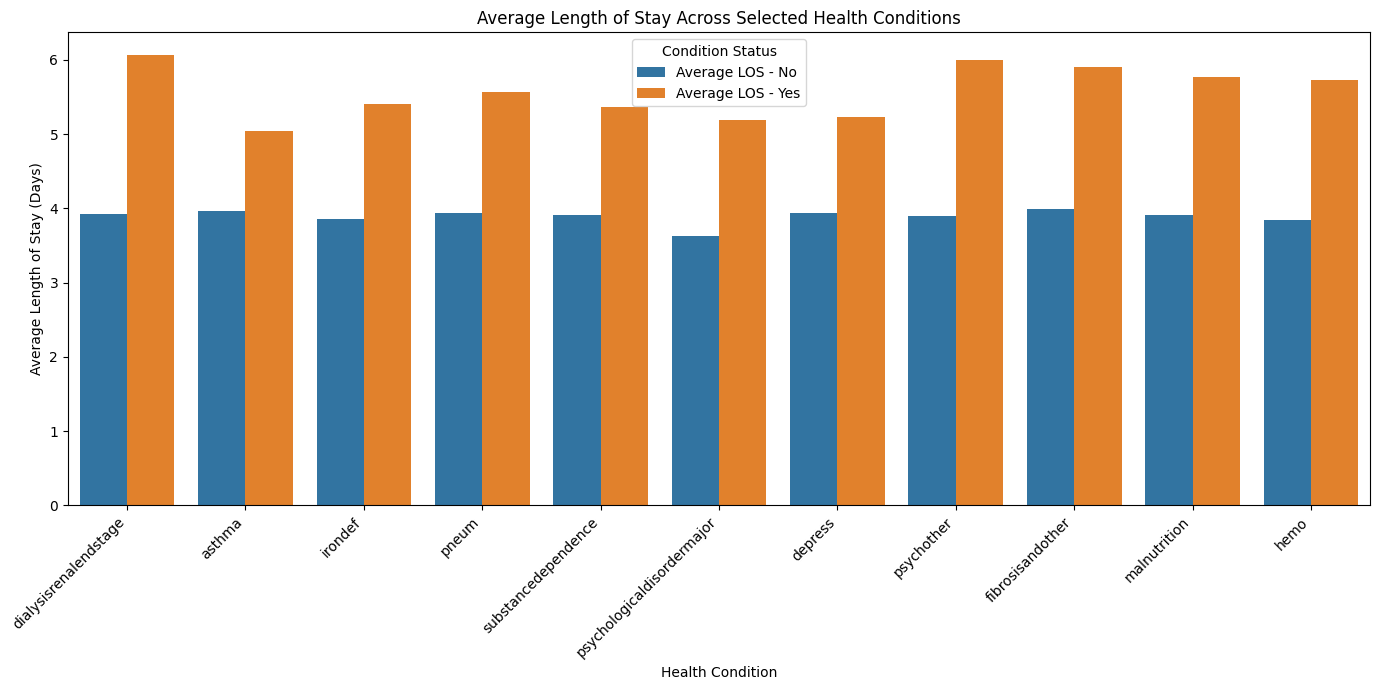

In [38]:
condition_plot = condition_mean_df.melt(
    id_vars="Condition",
    value_vars=[
        "Average LOS - No",
        "Average LOS - Yes"
    ],
    var_name="Condition Status",
    value_name="Average Length of Stay"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=condition_plot,
    x="Condition",
    y="Average Length of Stay",
    hue="Condition Status"
)

plt.title("Average Length of Stay Across Selected Health Conditions")
plt.xlabel("Health Condition")
plt.ylabel("Average Length of Stay (Days)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [39]:
numerical_features = [
    "hematocrit",
    "neutrophils",
    "sodium",
    "glucose",
    "bloodureanitro",
    "creatinine",
    "bmi",
    "pulse",
    "respiration",
    "secondarydiagnosisnonicd9"
]

correlation_with_target = (
    clean_df[numerical_features + ["lengthofstay"]]
    .corr()["lengthofstay"]
    .sort_values(ascending=False)
)

display(correlation_with_target)

,lengthofstay
lengthofstay,1.000000
bloodureanitro,0.151434
secondarydiagnosisnonicd9,0.005963
pulse,0.005168
glucose,0.000810
bmi,-0.000494
sodium,-0.003620
creatinine,-0.007101
neutrophils,-0.008652
respiration,-0.021122


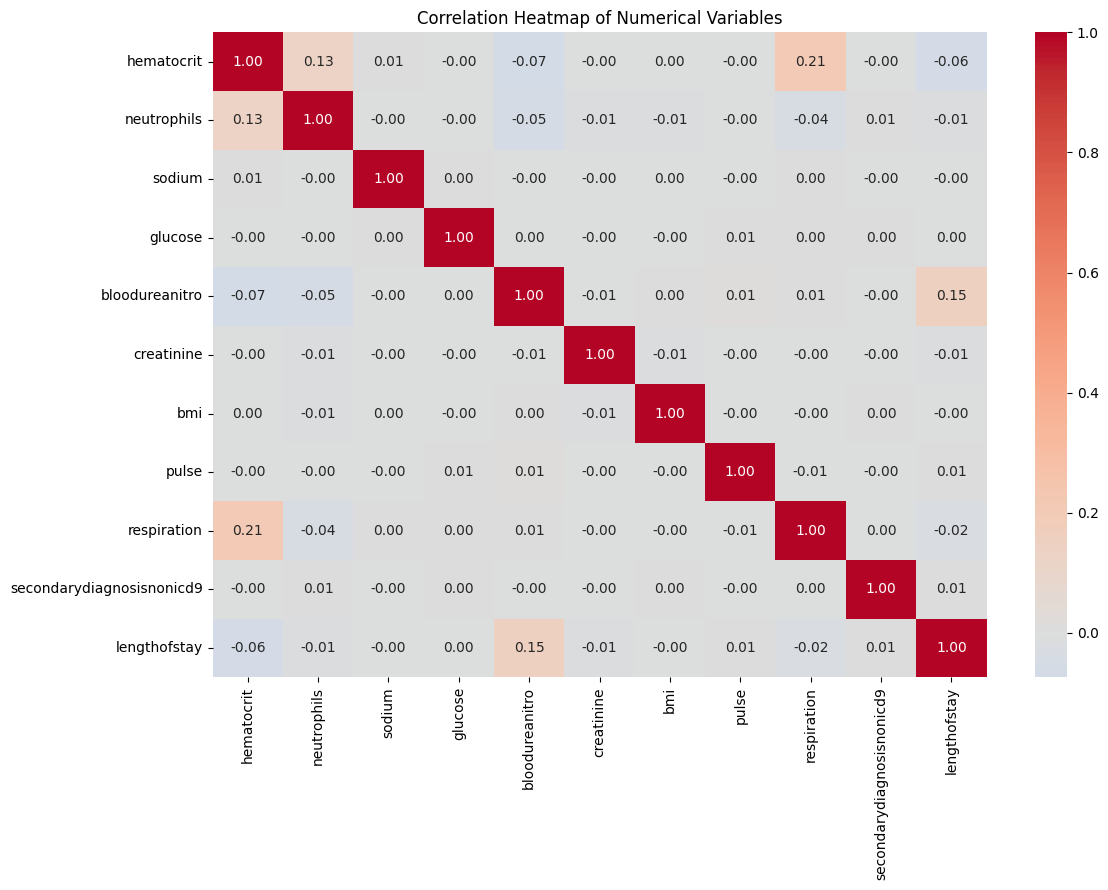

In [40]:
plt.figure(figsize=(12, 9))

correlation_matrix = clean_df[
    numerical_features + ["lengthofstay"]
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

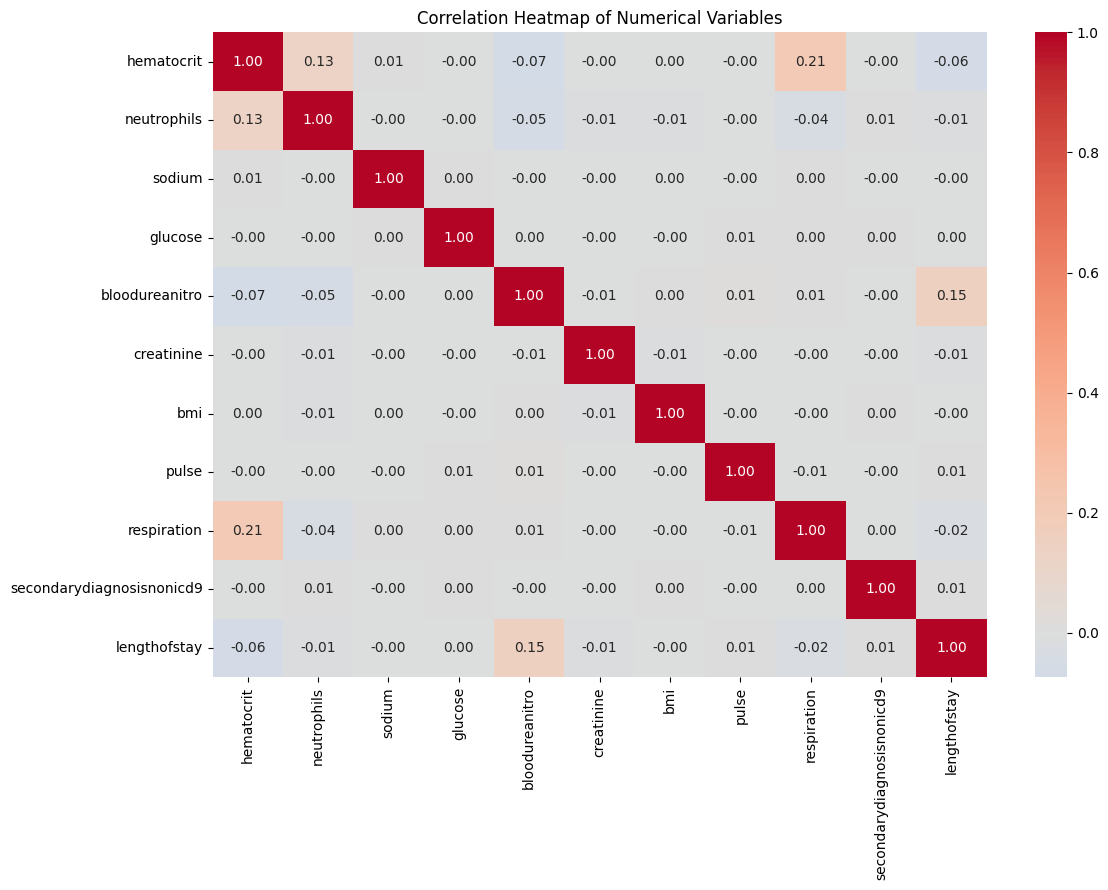

In [41]:
plt.figure(figsize=(12, 9))

correlation_matrix = clean_df[
    numerical_features + ["lengthofstay"]
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

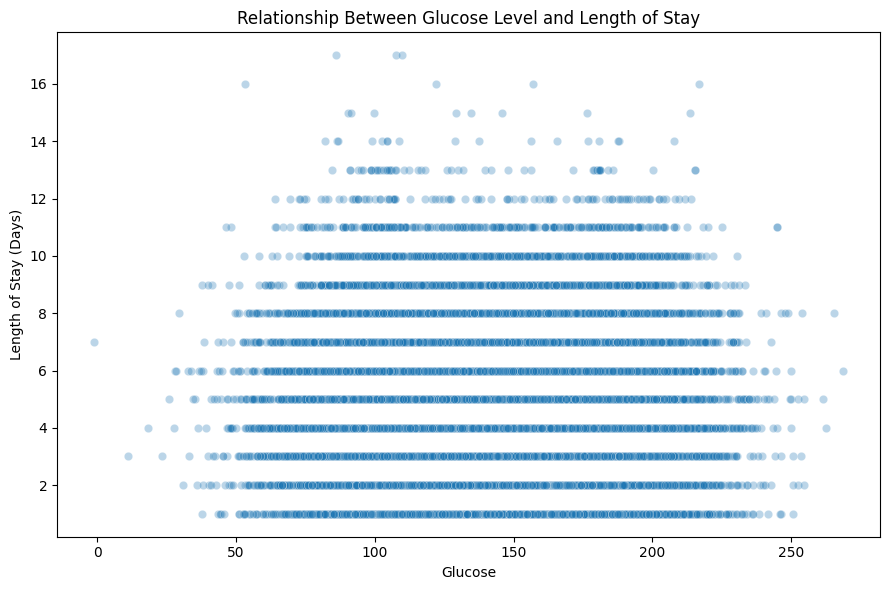

In [42]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=clean_df,
    x="glucose",
    y="lengthofstay",
    alpha=0.3
)

plt.title("Relationship Between Glucose Level and Length of Stay")
plt.xlabel("Glucose")
plt.ylabel("Length of Stay (Days)")

plt.tight_layout()
plt.show()

In [43]:
statistical_summary = clean_df[
    numerical_features + ["lengthofstay"]
].describe().T

statistical_summary["median"] = clean_df[
    numerical_features + ["lengthofstay"]
].median()

statistical_summary["variance"] = clean_df[
    numerical_features + ["lengthofstay"]
].var()

statistical_summary["IQR"] = (
    clean_df[numerical_features + ["lengthofstay"]].quantile(0.75)
    -
    clean_df[numerical_features + ["lengthofstay"]].quantile(0.25)
)

display(statistical_summary)

,count,mean,std,min,25%,50%,75%,max,median,variance,IQR
hematocrit,61680.0,11.966872,2.038621,4.400000,10.900000,11.900000,12.900000,24.100000,11.900000,4.155977,2.000000
neutrophils,61680.0,10.196406,5.271263,0.100000,7.700000,9.400000,11.500000,245.900000,9.400000,27.786214,3.800000
sodium,61680.0,137.896793,3.000727,124.912632,135.874040,137.900871,139.914345,151.387283,137.900871,9.004362,4.040305
glucose,61680.0,142.052746,29.923142,-1.005927,121.873358,142.249278,162.207568,268.571156,142.249278,895.394439,40.334210
bloodureanitro,61680.0,14.113017,12.749797,1.000000,11.000000,12.000000,14.000000,682.500000,12.000000,162.557322,3.000000
creatinine,61680.0,1.099037,0.200437,0.219770,0.964564,1.098405,1.235104,2.035202,1.098405,0.040175,0.270540
bmi,61680.0,29.803679,2.000390,22.037695,28.456682,29.804745,31.152721,38.935293,29.804745,4.001560,2.696039
pulse,61680.0,73.422568,11.651837,21.000000,66.000000,73.000000,81.000000,126.000000,73.000000,135.765304,15.000000
respiration,61680.0,6.492793,0.572551,0.200000,6.500000,6.500000,6.500000,10.000000,6.500000,0.327815,0.000000
secondarydiagnosisnonicd9,61680.0,2.122455,2.053596,0.000000,1.000000,1.000000,3.000000,10.000000,1.000000,4.217255,2.000000


In [44]:
model_df = clean_df.copy()

print("Model dataset shape:", model_df.shape)

Model dataset shape: (61680, 31)


In [45]:
columns_to_drop = [
    "eid",
    "vdate",
    "discharged",
    "lengthofstay"
]

X = model_df.drop(columns=columns_to_drop)

y = model_df["lengthofstay"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("lengthofstay")

Feature matrix shape: (61680, 27)
Target shape: (61680,)

Features:
['rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'facid', 'admission_year', 'admission_month', 'admission_dayofweek']

Target:
lengthofstay


In [46]:
categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features_model = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features_model)

Categorical features:
['rcount', 'gender', 'facid']

Numerical features:
['dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9']


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 49344
Testing samples: 12336


In [48]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numerical_features_model
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [49]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [50]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [52]:
y_train_pred_linear = linear_model.predict(X_train)
y_test_pred_linear = linear_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [53]:
linear_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_linear
)

linear_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_linear
)

linear_train_mse = mean_squared_error(
    y_train,
    y_train_pred_linear
)

linear_test_mse = mean_squared_error(
    y_test,
    y_test_pred_linear
)

linear_train_rmse = np.sqrt(linear_train_mse)
linear_test_rmse = np.sqrt(linear_test_mse)

linear_train_r2 = r2_score(
    y_train,
    y_train_pred_linear
)

linear_test_r2 = r2_score(
    y_test,
    y_test_pred_linear
)

linear_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],
    "Training": [
        linear_train_mae,
        linear_train_mse,
        linear_train_rmse,
        linear_train_r2
    ],
    "Testing": [
        linear_test_mae,
        linear_test_mse,
        linear_test_rmse,
        linear_test_r2
    ]
})

display(linear_results)

,Metric,Training,Testing
0,MAE,0.878919,0.865515
1,MSE,1.321725,1.292443
2,RMSE,1.149663,1.136857
3,R²,0.762997,0.764429


In [54]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


In [55]:
y_train_pred_rf = random_forest_model.predict(X_train)
y_test_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [56]:
rf_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_rf
)

rf_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_rf
)

rf_train_mse = mean_squared_error(
    y_train,
    y_train_pred_rf
)

rf_test_mse = mean_squared_error(
    y_test,
    y_test_pred_rf
)

rf_train_rmse = np.sqrt(rf_train_mse)
rf_test_rmse = np.sqrt(rf_test_mse)

rf_train_r2 = r2_score(
    y_train,
    y_train_pred_rf
)

rf_test_r2 = r2_score(
    y_test,
    y_test_pred_rf
)

rf_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],
    "Training": [
        rf_train_mae,
        rf_train_mse,
        rf_train_rmse,
        rf_train_r2
    ],
    "Testing": [
        rf_test_mae,
        rf_test_mse,
        rf_test_rmse,
        rf_test_r2
    ]
})

display(rf_results)

,Metric,Training,Testing
0,MAE,0.157757,0.412776
1,MSE,0.066994,0.458399
2,RMSE,0.258832,0.677052
3,R²,0.987987,0.916449


In [57]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression"
    ],

    "Test MAE": [
        linear_test_mae,
        rf_test_mae
    ],

    "Test MSE": [
        linear_test_mse,
        rf_test_mse
    ],

    "Test RMSE": [
        linear_test_rmse,
        rf_test_rmse
    ],

    "Test R²": [
        linear_test_r2,
        rf_test_r2
    ]
})

display(model_comparison)

,Model,Test MAE,Test MSE,Test RMSE,Test R²
0,Linear Regression,0.865515,1.292443,1.136857,0.764429
1,Random Forest Regression,0.412776,0.458399,0.677052,0.916449


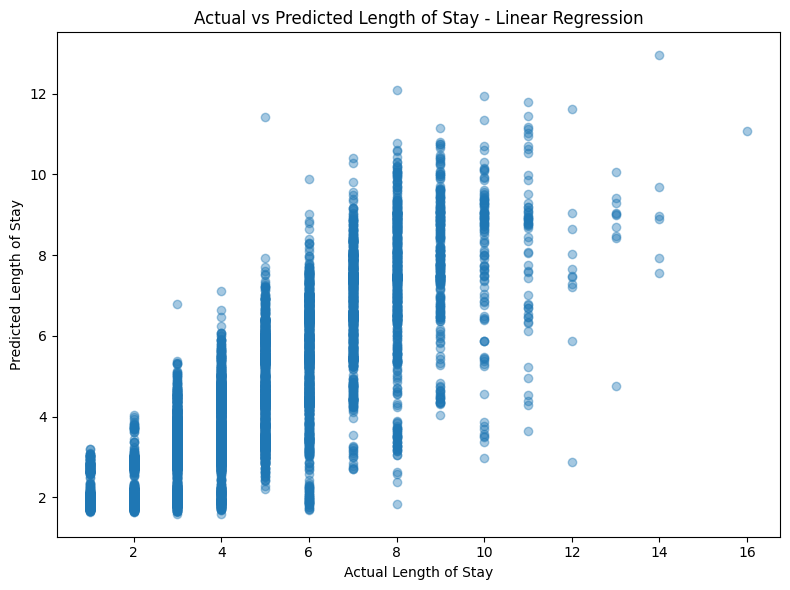

In [58]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred_linear,
    alpha=0.4
)

plt.xlabel("Actual Length of Stay")
plt.ylabel("Predicted Length of Stay")
plt.title("Actual vs Predicted Length of Stay - Linear Regression")

plt.tight_layout()
plt.show()

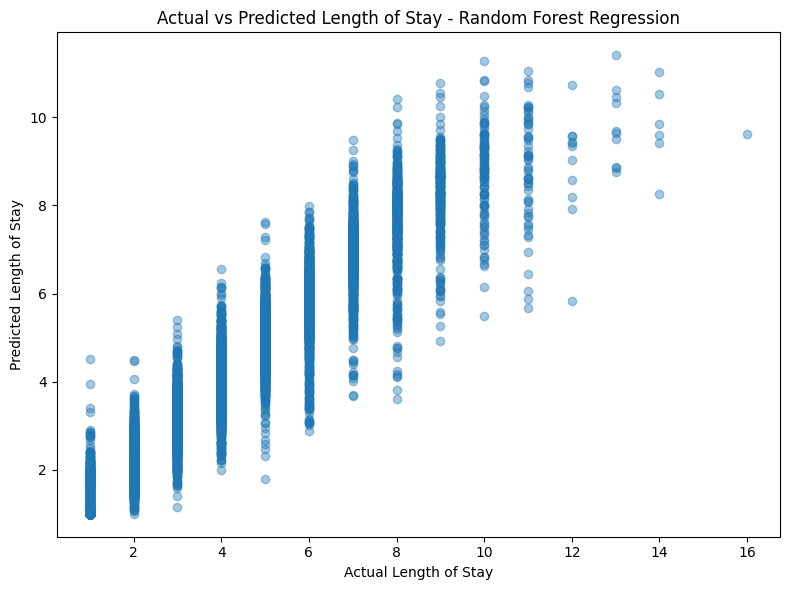

In [59]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred_rf,
    alpha=0.4
)

plt.xlabel("Actual Length of Stay")
plt.ylabel("Predicted Length of Stay")
plt.title("Actual vs Predicted Length of Stay - Random Forest Regression")

plt.tight_layout()
plt.show()

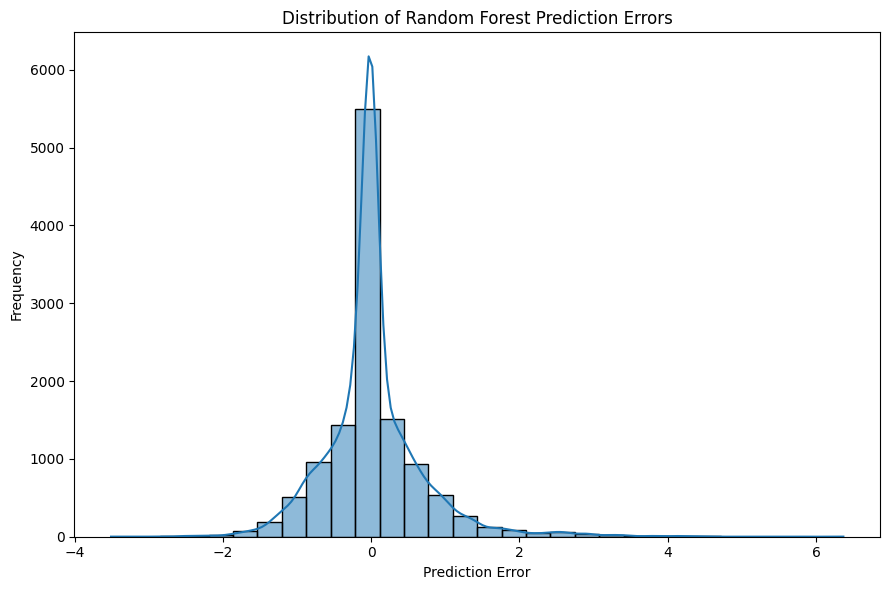

In [60]:
residuals_rf = y_test - y_test_pred_rf

plt.figure(figsize=(9, 6))

sns.histplot(
    residuals_rf,
    bins=30,
    kde=True
)

plt.title("Distribution of Random Forest Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

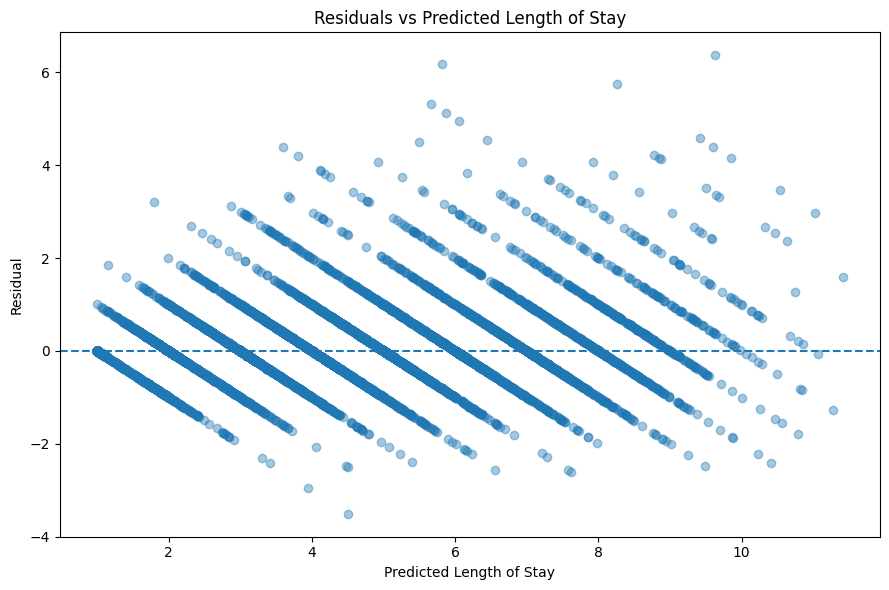

In [61]:
plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_pred_rf,
    residuals_rf,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residuals vs Predicted Length of Stay")
plt.xlabel("Predicted Length of Stay")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

In [62]:
rf_pipeline = random_forest_model

trained_preprocessor = rf_pipeline.named_steps["preprocessor"]
trained_rf = rf_pipeline.named_steps["model"]

feature_names = trained_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": trained_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
21,categorical__rcount_0,0.357441
22,categorical__rcount_1,0.140547
33,categorical__facid_E,0.114982
11,numeric__hematocrit,0.044879
23,categorical__rcount_2,0.041140
10,numeric__hemo,0.029244
19,numeric__respiration,0.029011
16,numeric__creatinine,0.025712
13,numeric__sodium,0.025376
17,numeric__bmi,0.025156


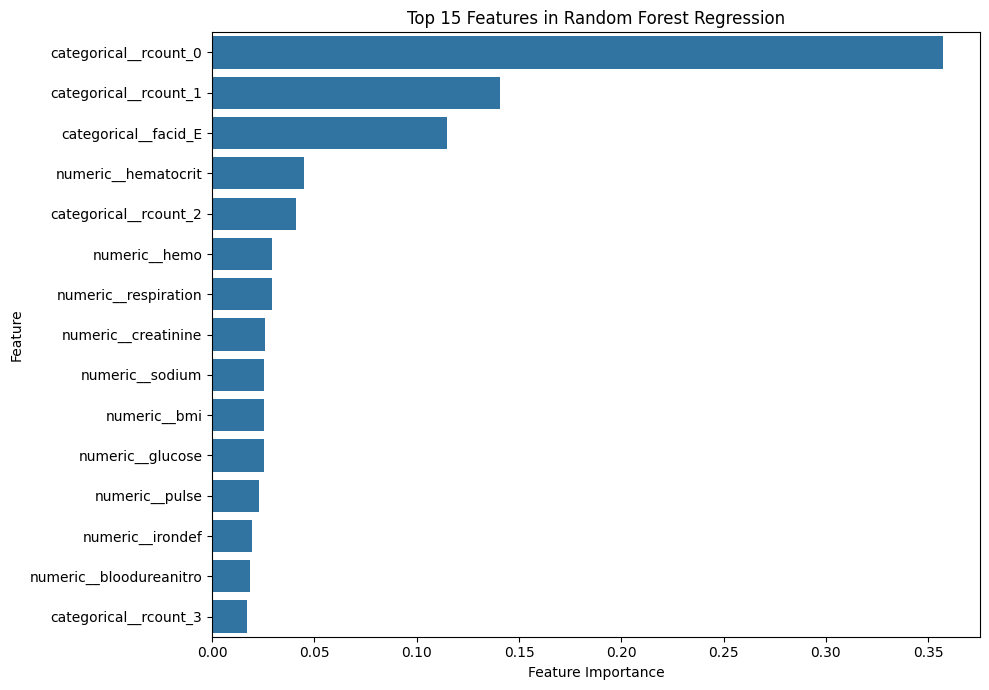

In [63]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features in Random Forest Regression")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [64]:
cleaned_file = "P_1_LengthOfStay_Cleaned.csv"

clean_df.to_csv(
    cleaned_file,
    index=False
)

print("Cleaned dataset saved as:", cleaned_file)

Cleaned dataset saved as: P_1_LengthOfStay_Cleaned.csv


In [65]:
from google.colab import files

files.download("P_1_LengthOfStay_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
print("="*60)
print("FINAL DATASET QUALITY CHECK")
print("="*60)

print("Original rows:", df.shape[0])
print("Cleaned rows:", clean_df.shape[0])

print("\nOriginal columns:", df.shape[1])
print("Cleaned columns:", clean_df.shape[1])

print("\nMissing values remaining:")
print(clean_df.isnull().sum().sum())

print("\nDuplicate rows remaining:")
print(clean_df.duplicated().sum())

print("\nTarget variable:")
print("lengthofstay")

print("\nTarget mean:")
print(clean_df["lengthofstay"].mean())

print("\nTarget median:")
print(clean_df["lengthofstay"].median())

print("\nTarget standard deviation:")
print(clean_df["lengthofstay"].std())

print("\nAnalysis completed successfully!")

FINAL DATASET QUALITY CHECK
Original rows: 61680
Cleaned rows: 61680

Original columns: 28
Cleaned columns: 31

Missing values remaining:
0

Duplicate rows remaining:
0

Target variable:
lengthofstay

Target mean:
3.9993677042801554

Target median:
4.0

Target standard deviation:
2.357744277645191

Analysis completed successfully!


In [67]:
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

display(
    model_comparison.round(4)
)

FINAL MODEL COMPARISON


,Model,Test MAE,Test MSE,Test RMSE,Test R²
0,Linear Regression,0.8655,1.2924,1.1369,0.7644
1,Random Forest Regression,0.4128,0.4584,0.6771,0.9164


In [68]:
best_model_row = model_comparison.loc[
    model_comparison["Test R²"].idxmax()
]

print("Model with the highest test R²:")
print(best_model_row["Model"])

print("\nTest MAE:", round(best_model_row["Test MAE"], 4))
print("Test MSE:", round(best_model_row["Test MSE"], 4))
print("Test RMSE:", round(best_model_row["Test RMSE"], 4))
print("Test R²:", round(best_model_row["Test R²"], 4))

Model with the highest test R²:
Random Forest Regression

Test MAE: 0.4128
Test MSE: 0.4584
Test RMSE: 0.6771
Test R²: 0.9164


In [69]:
print("="*70)
print("CAPSTONE PROJECT SUMMARY")
print("="*70)

print("\nProject:")
print("Predictive Analytics for Healthcare: Forecasting Patient Length of Stay in Urban Hospitals")

print("\nDataset:")
print("P_1_LengthOfStay.csv")

print("\nOriginal dataset shape:")
print(df.shape)

print("\nCleaned dataset shape:")
print(clean_df.shape)

print("\nTarget variable:")
print("lengthofstay")

print("\nProblem type:")
print("Regression")

print("\nModels developed:")
print("1. Linear Regression")
print("2. Random Forest Regression")

print("\nFinal model comparison:")
display(model_comparison.round(4))

print("\nProject analysis completed.")

CAPSTONE PROJECT SUMMARY

Project:
Predictive Analytics for Healthcare: Forecasting Patient Length of Stay in Urban Hospitals

Dataset:
P_1_LengthOfStay.csv

Original dataset shape:
(61680, 28)

Cleaned dataset shape:
(61680, 31)

Target variable:
lengthofstay

Problem type:
Regression

Models developed:
1. Linear Regression
2. Random Forest Regression

Final model comparison:


,Model,Test MAE,Test MSE,Test RMSE,Test R²
0,Linear Regression,0.8655,1.2924,1.1369,0.7644
1,Random Forest Regression,0.4128,0.4584,0.6771,0.9164



Project analysis completed.
